In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [2]:
df = pd.read_csv('airline_passengers.csv', index_col = 'Month', parse_dates = True)

In [3]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


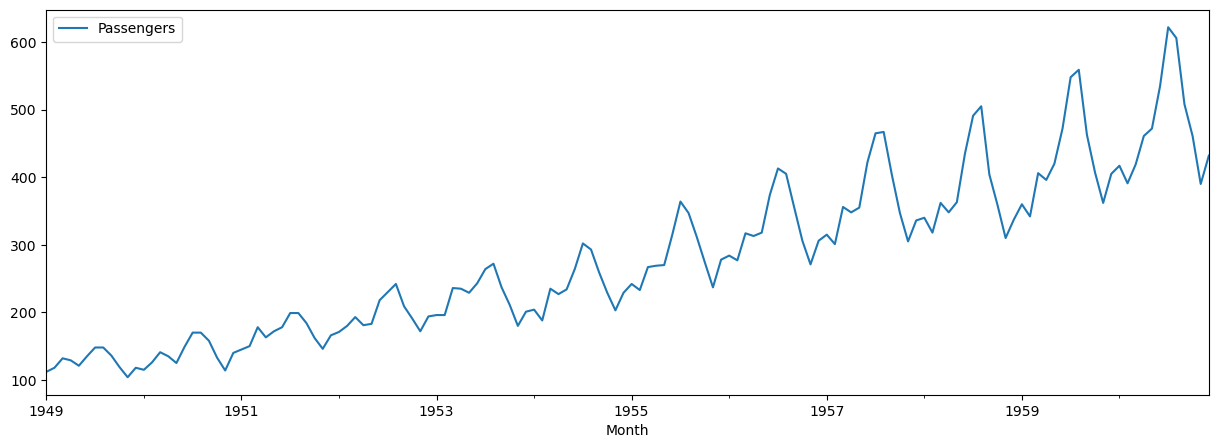

In [4]:
df.plot(figsize = (15,5));

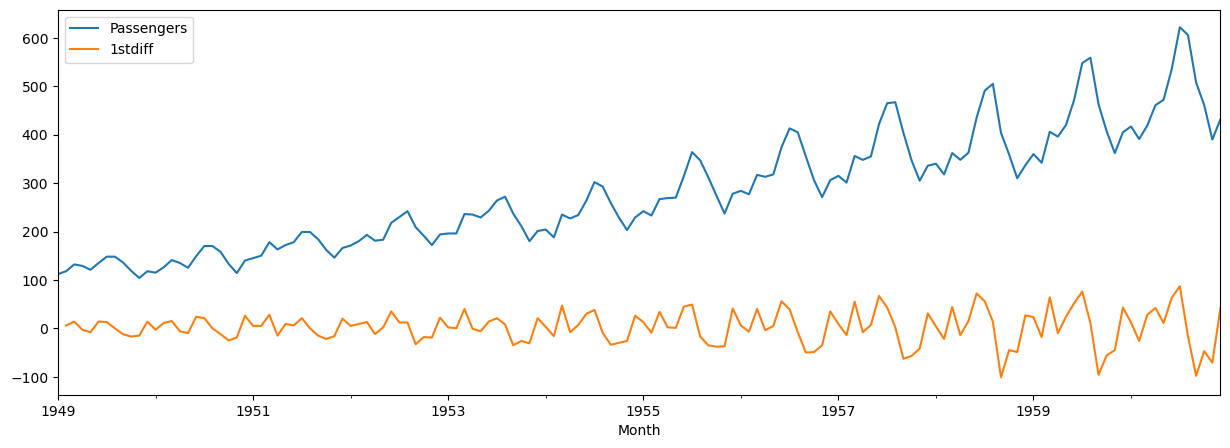

In [5]:
df['1stdiff'] = df['Passengers'].diff()
df.plot(figsize = (15,5));

In [6]:
df.to_clipboard()

In [8]:
"""data not looking quite stationary - the variation is increasing over time"""

'data not looking quite stationary - the variation is increasing over time'

In [9]:
df['LogPassengers'] = np.log(df['Passengers'])

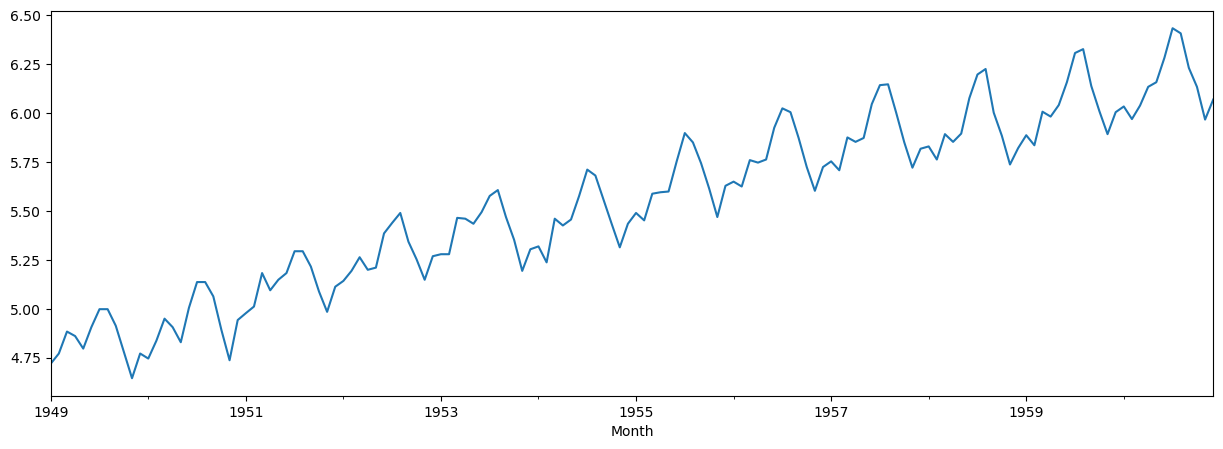

In [10]:
df['LogPassengers'].plot(figsize = (15,5));

In [11]:
""" not the amplitude of the seasonality doesnt increase over time.
if we take the 1st diff now, then data should look stationary.
As mentioned in the notes, log transforming before taking 1st diff might help with data becoming more stationary and also in volatility clustering""" 

' not the amplitude of the seasonality doesnt increase over time.\nif we take the 1st diff now, then data should look stationary.\nAs mentioned in the notes, log transforming before taking 1st diff might help with data becoming more stationary and also in volatility clustering'

In [12]:
df['1stDiffLogPassengers'] = df['LogPassengers'].diff()

In [13]:
df.columns

Index(['Passengers', '1stdiff', 'LogPassengers', '1stDiffLogPassengers'], dtype='object')

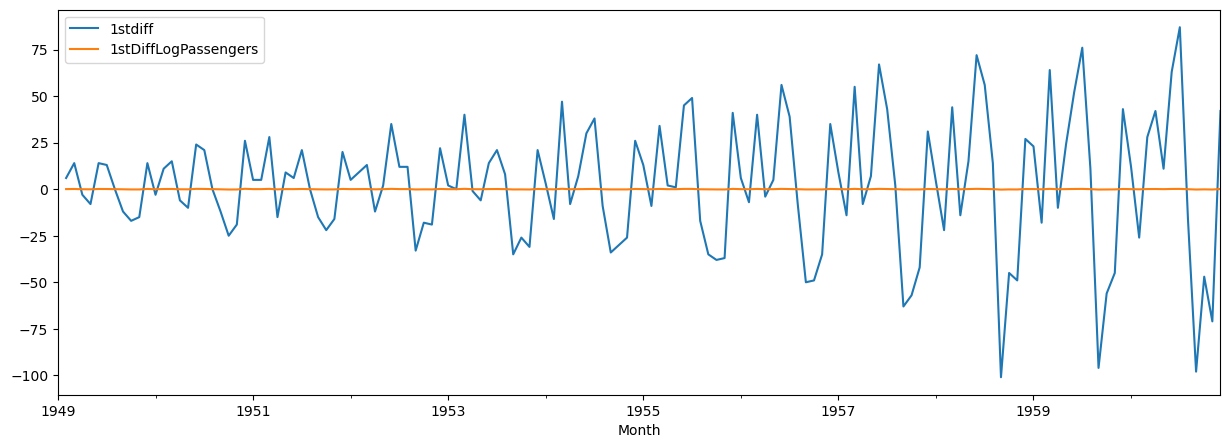

In [15]:
df[['1stdiff','1stDiffLogPassengers']].plot(figsize = (15,5)); 

In [69]:
"""1st diff of log passengers data is very stationary compared to taking 1st diff of normal passengers.
there is fluctuations in 1stdifflogpassengers but since we are looking at 1stdiff as well, it is nbot visible 
1st diff of log passengers also fluctuates in the tune of +-0.2 as displayed in the below sections, which is much less than 1st diff.
MOST IMPORTANTLY, 1ST DIFF COLUMN FLUCTUATIONS INCREASE OVER TIME , BUT AS DISPLAYED LATER ON 1ST DIFF LOG PASSENGERS FLUCTUATUATIONS DONT INCREASE OVER TIME
"""

'1st diff of log passengers data is very stationary compared to taking 1st diff of normal passengers.\nthere is fluctuations in 1stdifflogpassengers but since we are looking at 1stdiff as well, it is nbot visible \n1st diff of log passengers also fluctuates in the tune of +-0.2 as displayed in the below sections, which is much less than 1st diff.\nMOST IMPORTANTLY, 1ST DIFF COLUMN FLUCTUATIONS INCREASE OVER TIME , BUT AS DISPLAYED LATER ON 1ST DIFF LOG PASSENGERS FLUCTUATUATIONS DONT INCREASE OVER TIME\n'

In [18]:
df.drop('1stDiffLogPassengers', axis=1,inplace=True)

In [19]:
df.columns

Index(['Passengers', '1stdiff', 'LogPassengers'], dtype='object')

In [20]:
from statsmodels.tsa.arima.model import ARIMA

In [21]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [22]:
df.index.freq = 'MS'

In [24]:
Ntest = 12

train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

train_idx =  df.index <= train.index[-1]
test_idx = df.index > train.index[-1]

In [26]:
''' the below is AR(1) model which says data just depends on the previous values linearly
THIS IS NOT RANDOM WALK SINCE, IN RANDOM WALK NEXT VALUE IS EQUAL TO 1*PREVIOUS VALUE + ERROR, BUT IN THE BELOW IT COULD BE 0.8 * PREVIOUS VALUE + ERROR'''

arima = ARIMA(train['Passengers'], order = (1,0,0))
              

In [27]:
arima_result = arima.fit()

In [28]:
df.loc[train_idx, 'AR(1)'] = arima_result.predict(start = train.index[0], end = train.index[-1])

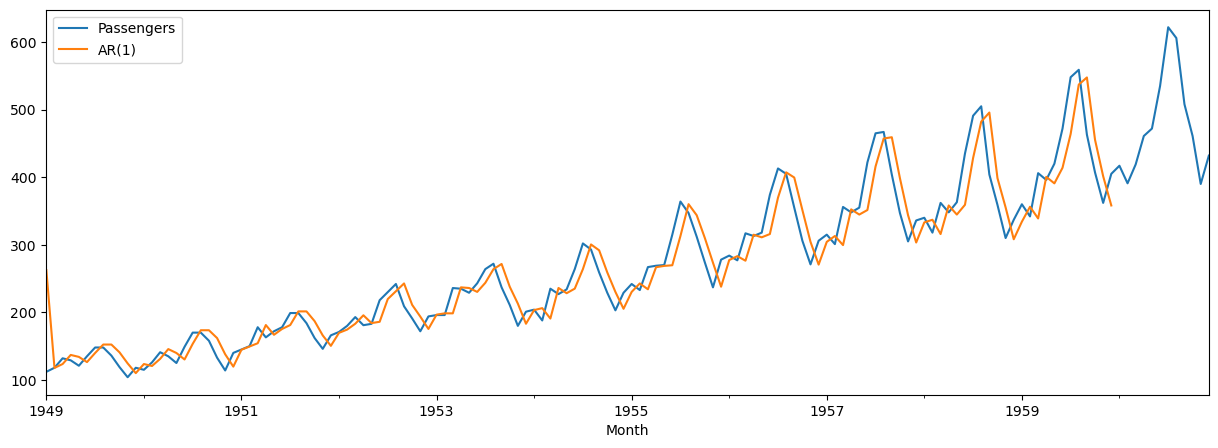

In [30]:
df[['Passengers','AR(1)']].plot(figsize = (15,5));

In [35]:
'''this is how holt winters also behaved
just copying the previous values
'''

'this is how holt winters also behaved\njust copying the previous values\n'

In [33]:
arima_result.params

const     262.490027
ar.L1       0.961791
sigma2    965.362772
dtype: float64

In [40]:
prediction_result = arima_result.get_forecast(Ntest) # this doesnt result the numerical data directly but the prediction object is returned
forecast = prediction_result.predicted_mean #'''we can also call confidence intervals'''
df.loc[test_idx, 'AR(1)'] = forecast

In [41]:
prediction_result

In [42]:
type(forecast)

pandas.core.series.Series

In [43]:
forecast

1960-01-01    399.554855
1960-02-01    394.317763
1960-03-01    389.280774
1960-04-01    384.436243
1960-05-01    379.776816
1960-06-01    375.295420
1960-07-01    370.985253
1960-08-01    366.839773
1960-09-01    362.852687
1960-10-01    359.017944
1960-11-01    355.329721
1960-12-01    351.782421
Freq: MS, Name: predicted_mean, dtype: float64

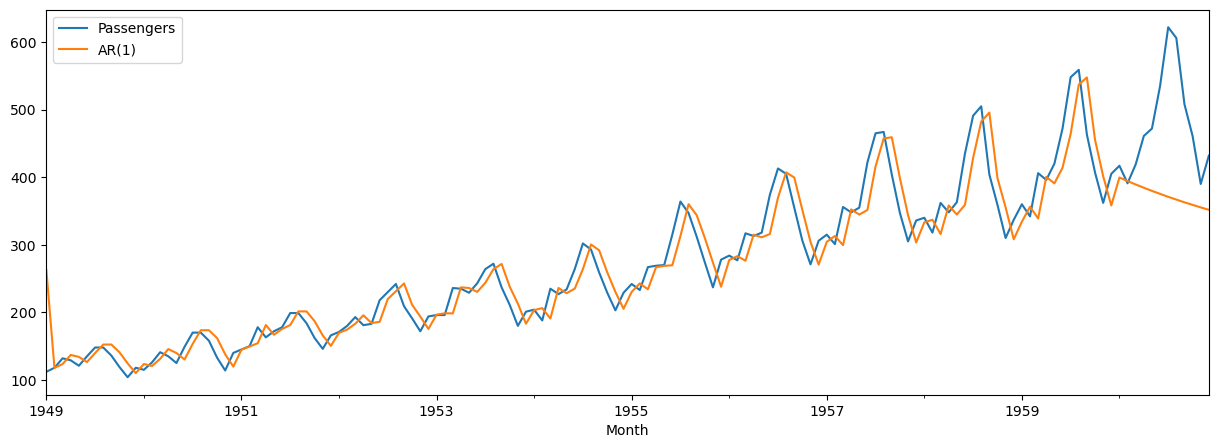

In [44]:
df[['Passengers','AR(1)']].plot(figsize = (15,5));

In [47]:
''' even a naive forecast is better than this'''

' even a naive forecast is better than this'

In [46]:
type(prediction_result)

statsmodels.tsa.statespace.mlemodel.PredictionResultsWrapper

In [48]:
prediction_result.conf_int()

,lower Passengers,upper Passengers
1960-01-01,338.658210,460.451500
1960-02-01,309.826172,478.809354
1960-03-01,287.732169,490.829379
1960-04-01,269.338256,499.534230
1960-05-01,253.432284,506.121347
1960-06-01,239.373403,511.217437
1960-07-01,226.768868,515.201638
1960-08-01,215.354570,518.324977
1960-09-01,204.941150,520.764224
1960-10-01,195.386337,522.649550


In [50]:
arima_result.fittedvalues

Month
1949-01-01    262.490027
1949-02-01    117.750054
1949-03-01    123.520801
1949-04-01    136.985876
1949-05-01    134.100503
                 ...    
1959-08-01    537.090987
1959-09-01    547.670689
1959-10-01    455.338740
1959-11-01    401.478437
1959-12-01    358.197836
Freq: MS, Length: 132, dtype: float64

In [53]:
def plot_fit_and_forecast(result):
    fig, ax = plt.subplots(figsize = (15,5))
    ax.plot(df['Passengers'], label = 'data')

    # plot the curve fitted on train set
    train_pred = result.fittedvalues
    ax.plot(train.index, train_pred, color = 'green', label = 'fitted')

    # forecast the test set
    prediction_result = result.get_forecast(Ntest)
    conf_int = prediction_result.conf_int()
    lower, upper = conf_int['lower Passengers'], conf_int['upper Passengers']
    forecast = prediction_result.predicted_mean
    ax.plot(test.index, forecast, label ='forecast')
    ax.fill_between(test.index, lower, upper, color = 'red', alpha =  0.3)  # alpha is for transperancy

    ax.legend()
    

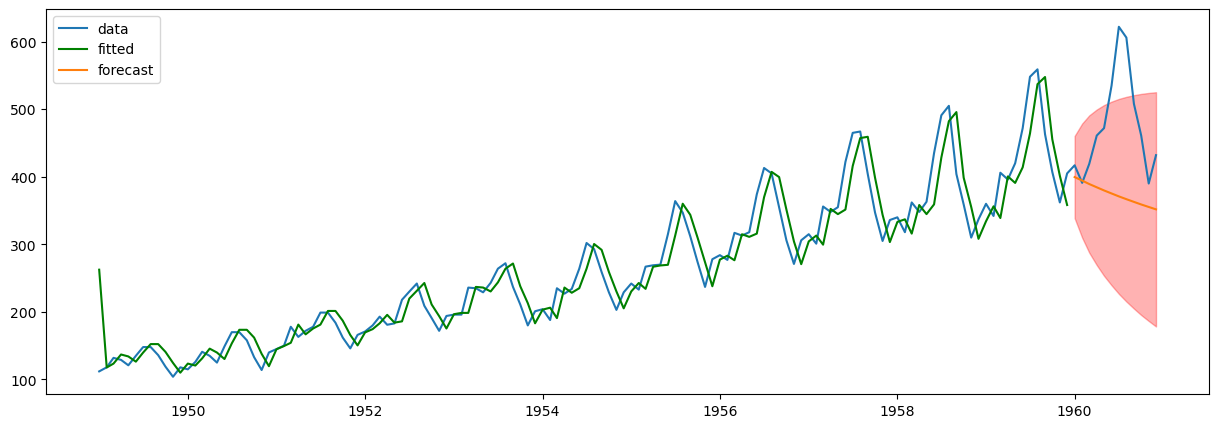

In [54]:
plot_fit_and_forecast(arima_result)

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


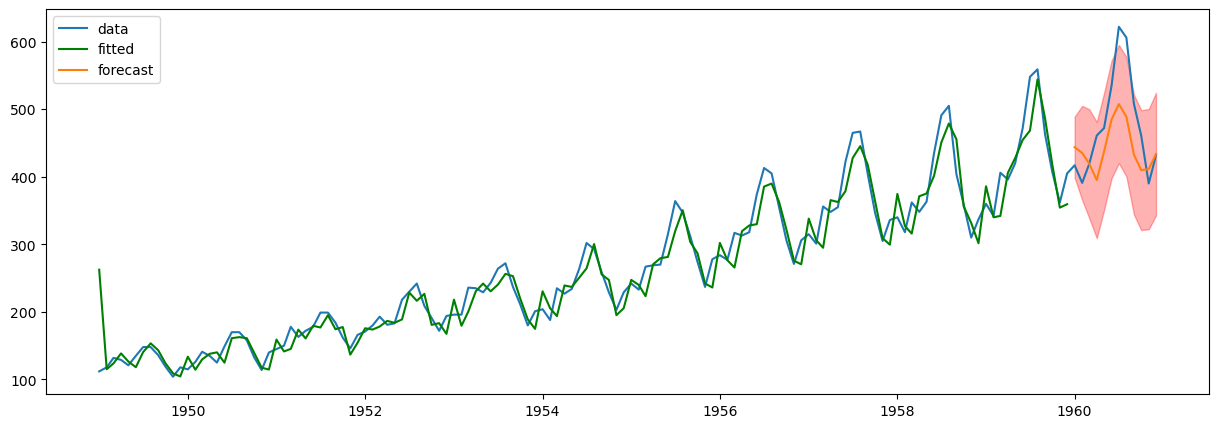

In [56]:
arima = ARIMA(train['Passengers'], order =  (10,0,0)) # AR(10)
# in ml, trying to add more data points from the past data values, past 10 data values
arima_result = arima.fit()
plot_fit_and_forecast(arima_result);

In [62]:
''' this does a much better job when we used last 10 data points which incorporated the hump/seasonality
but it is underestimating the true value in the test set
'''

' this does a much better job when we used last 10 data points which incorporated the hump/seasonality\nbut it is underestimating the true value in the test set\n'

<Axes: xlabel='Month'>

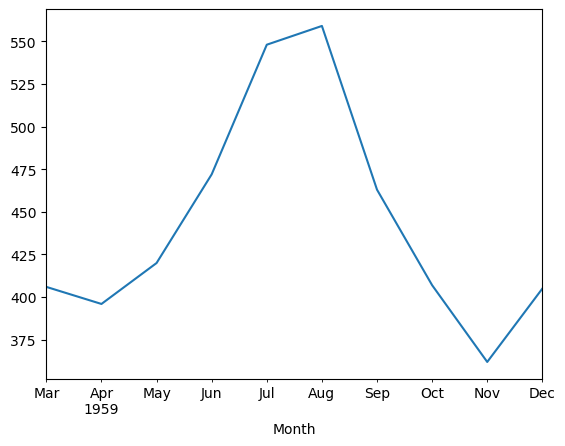

In [59]:
train['Passengers'].iloc[-10:].plot()

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


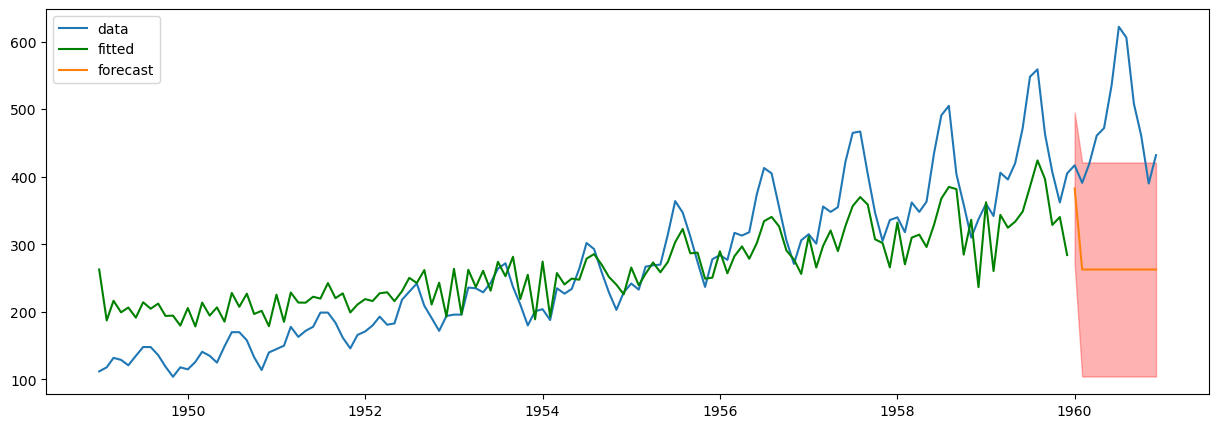

In [63]:
arima = ARIMA(train['Passengers'], order =  (0,0,1)) # MA(1)
arima_result = arima.fit()
plot_fit_and_forecast(arima_result);

In [64]:
'''MA model is always a constant value'''

'MA model is always a constant value'

In [65]:
df.columns

Index(['Passengers', '1stdiff', 'LogPassengers', 'AR(1)'], dtype='object')

In [66]:
df['Log1stDiff'] = df['LogPassengers'].diff() 

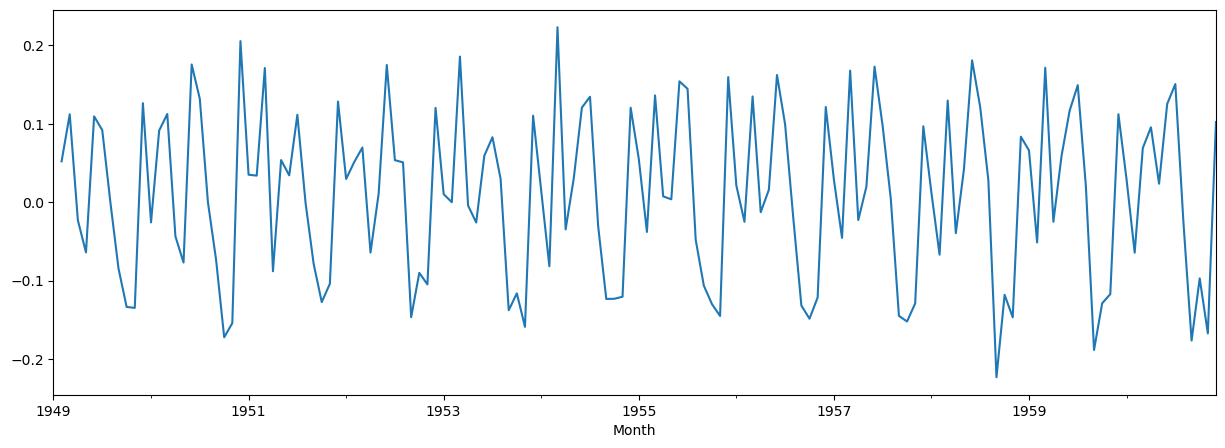

In [67]:
df['Log1stDiff'].plot(figsize = (15,5));

In [70]:
'''compared to the 1st diff of non logged transformed passengers ,where the fluctuations increase over time, log 1st diff dont increase over time
fluctiations are same across the time and doesnt increase'''

'compared to the 1st diff of non logged transformed passengers ,where the fluctuations increase over time, log 1st diff dont increase over time\nfluctiations are same across the time and doesnt increase'

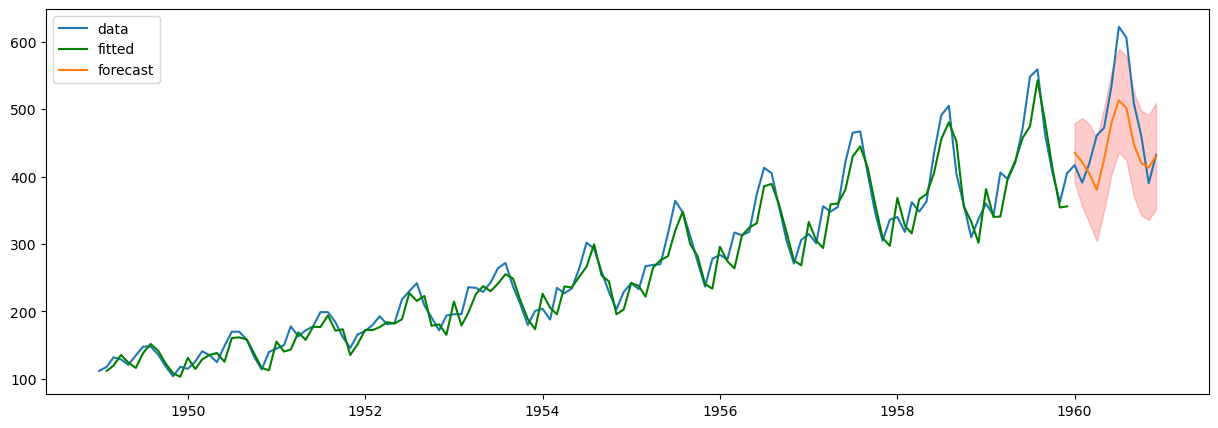

In [77]:
arima = ARIMA(train['Passengers'], order =  (8,1,1)) 
arima_result_811 = arima.fit()

def plot_fit_and_forecast_init(result, d, col='Passengers'):
    
    fig, ax = plt.subplots(figsize = (15,5))
    ax.plot(df[col], label ='data')

    train_pred =  result.predict(start = train.index[d], end = train.index[-1])
    # in the above, we are not using this ->  train_pred =  result.fittedvalues, since the 1st prediction is always 0, and it doesnt have functionality to
    # remove the 1st value hence using .predict(start, end)
    # we are using train.index[d] and not train.index[0] since 1st value at 0 index - prediction is 0
    ax.plot(train.index[d:], train_pred, color ='green', label ='fitted') #starting from dth point not from 0

    prediction_result = result.get_forecast(Ntest)
    conf_int = prediction_result.conf_int()
    lower, upper = conf_int[f'lower {col}'], conf_int[f'upper {col}']
    forecast = prediction_result.predicted_mean
    ax.plot(test.index, forecast, label = 'forecast')
    ax.fill_between(test.index, lower, upper, color ='red', alpha = 0.2)
    ax.legend()

plot_fit_and_forecast_init(arima_result_811,1)    
    

In [73]:
arima_result_811.predict(start = train.index[0], end = train.index[-1])

Month
1949-01-01      0.000000
1949-02-01    112.034074
1949-03-01    119.751782
1949-04-01    135.651836
1949-05-01    124.246604
                 ...    
1959-08-01    542.722017
1959-09-01    481.743121
1959-10-01    413.868014
1959-11-01    354.078873
1959-12-01    355.815473
Freq: MS, Name: predicted_mean, Length: 132, dtype: float64

In [74]:
arima_result_811.predict(start = train.index[1], end = train.index[-1])

Month
1949-02-01    112.034074
1949-03-01    119.751782
1949-04-01    135.651836
1949-05-01    124.246604
1949-06-01    116.279855
                 ...    
1959-08-01    542.722017
1959-09-01    481.743121
1959-10-01    413.868014
1959-11-01    354.078873
1959-12-01    355.815473
Freq: MS, Name: predicted_mean, Length: 131, dtype: float64

In [76]:
arima_result_811.fittedvalues

Month
1949-01-01      0.000000
1949-02-01    112.034074
1949-03-01    119.751782
1949-04-01    135.651836
1949-05-01    124.246604
                 ...    
1959-08-01    542.722017
1959-09-01    481.743121
1959-10-01    413.868014
1959-11-01    354.078873
1959-12-01    355.815473
Freq: MS, Length: 132, dtype: float64

In [79]:
df.columns

Index(['Passengers', '1stdiff', 'LogPassengers', 'AR(1)', 'Log1stDiff'], dtype='object')

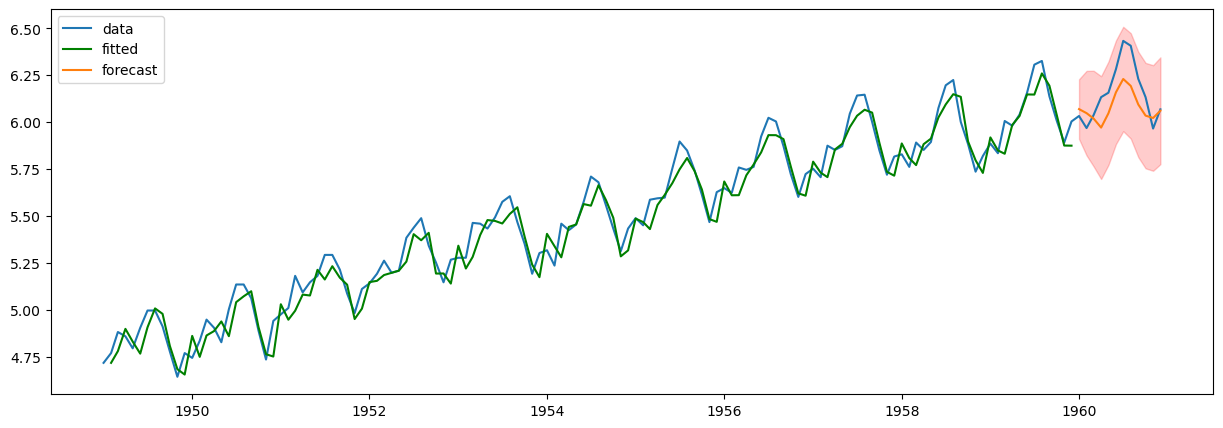

In [80]:
arima = ARIMA(train['LogPassengers'], order =  (8,1,1)) 
arima_result_log811 = arima.fit()
plot_fit_and_forecast_init(arima_result_log811,1, col ='LogPassengers' )    

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


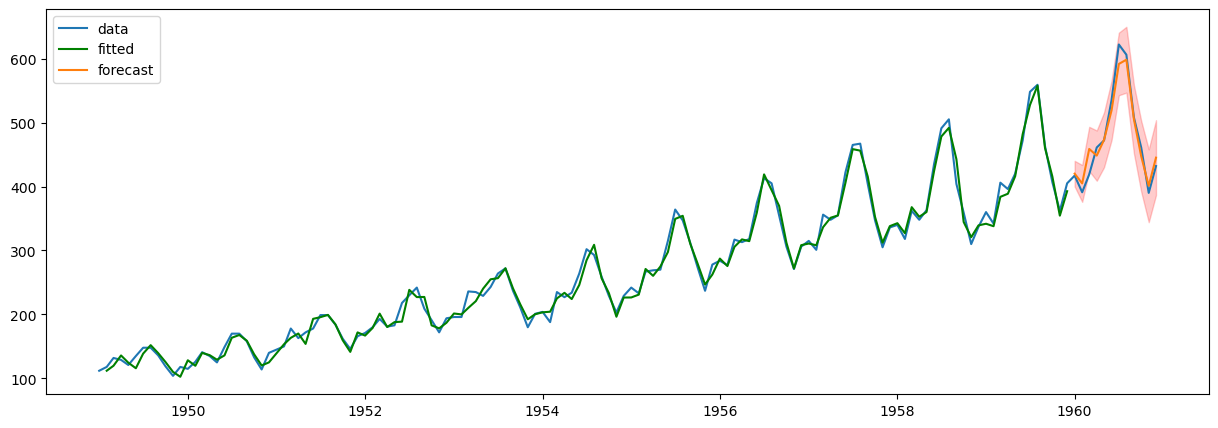

In [83]:
arima = ARIMA(train['Passengers'], order =  (12,1,0)) # using 12 since captures the whole year
arima_result_1210 = arima.fit()
plot_fit_and_forecast_init(arima_result_1210,1, col ='Passengers' )    

In [85]:
'''this seems like the best model so far. look at the test performance''' 

'this seems like the best model so far. look at the test performance'

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


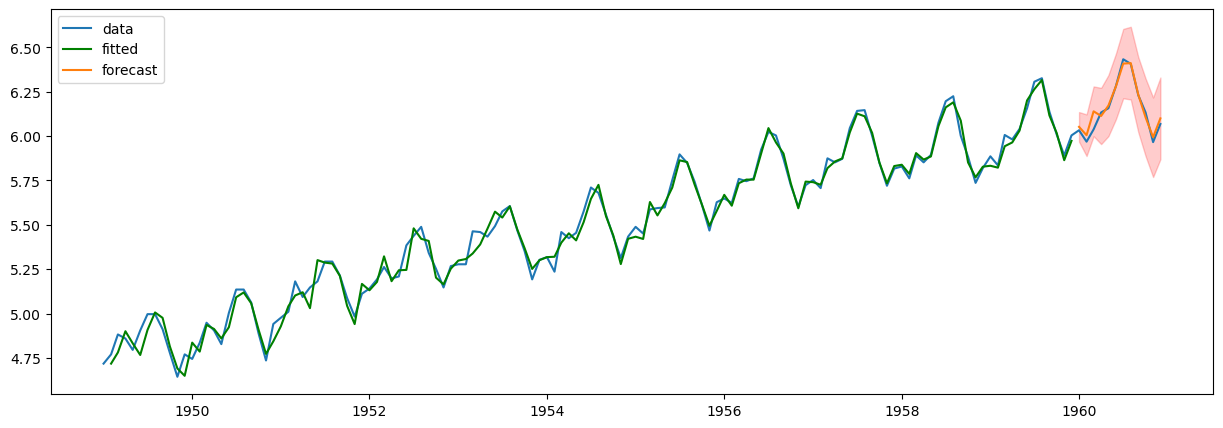

In [84]:
arima = ARIMA(train['LogPassengers'], order =  (12,1,0)) # using 12 since captures the whole year - using the same but with log passengers
arima_result_log1210 = arima.fit()
plot_fit_and_forecast_init(arima_result_log1210,1, col ='LogPassengers' )    

In [86]:
'''this is very close to previous model -  need to check with metric''' 

'this is very close to previous model -  need to check with metric'

In [87]:
def rmse(result, is_logged):
    forecast = result.forecast(Ntest)
    if is_logged:
        forecast = np.exp(forecast)

    t = test['Passengers']
    y = forecast
    return np.sqrt(np.mean((t-y)**2))

In [88]:
print("ARIMA(8,1,1):", rmse(arima_result_811,False))
print("ARIMA(8,1,1) logged:", rmse(arima_result_log811,True))
print("ARIMA(12,1,0):", rmse(arima_result_1210,False))
print("ARIMA(12,1,0) logged:", rmse(arima_result_log1210,True))

ARIMA(8,1,1): 59.06458597551526
ARIMA(8,1,1) logged: 61.60669217719531
ARIMA(12,1,0): 17.483875538470773
ARIMA(12,1,0) logged: 16.133073306366175


In [89]:
###the last model is the best model